In [280]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config

set_config(transform_output="pandas")

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [281]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [282]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [283]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [284]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [285]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Maintenant à partir de ce jeu de données on va créer un autre jeu de données mais dans lequel les lignes seront les clients et non les transactions. On va créer facile à créer en prenant juste les moyeenes, somme et les fréquences de chaque variable. On va pour les dates calculer la récence et l'ancieneté.

In [286]:
frequence = df.groupby("CustomerID")["InvoiceNo"].nunique()
data = pd.DataFrame({"frequence": frequence})
data

,frequence
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [287]:
data["nb_produit"] = df.groupby("CustomerID")["StockCode"].count()
data

,frequence,nb_produit
CustomerID,,
12346.0,1,1
12347.0,7,182
12348.0,4,31
12349.0,1,73
12350.0,1,17
...,...,...
18280.0,1,10
18281.0,1,7
18282.0,2,12


In [288]:
data["quantité_moyenne"] = df.groupby("CustomerID")["Quantity"].mean()
data

,frequence,nb_produit,quantité_moyenne
CustomerID,,,
12346.0,1,1,74215.000000
12347.0,7,182,13.505495
12348.0,4,31,75.516129
12349.0,1,73,8.643836
12350.0,1,17,11.588235
...,...,...,...
18280.0,1,10,4.500000
18281.0,1,7,7.714286
18282.0,2,12,8.583333


In [289]:
data["quantité_totale"] = df.groupby("CustomerID")["Quantity"].sum()
data

,frequence,nb_produit,quantité_moyenne,quantité_totale
CustomerID,,,,
12346.0,1,1,74215.000000,74215
12347.0,7,182,13.505495,2458
12348.0,4,31,75.516129,2341
12349.0,1,73,8.643836,631
12350.0,1,17,11.588235,197
...,...,...,...,...
18280.0,1,10,4.500000,45
18281.0,1,7,7.714286,54
18282.0,2,12,8.583333,103


In [290]:
from datetime import timedelta

recence = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].max()
    + timedelta(days=1)
).dt.days
data["recence"] = recence
data

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence
CustomerID,,,,,
12346.0,1,1,74215.000000,74215,326
12347.0,7,182,13.505495,2458,2
12348.0,4,31,75.516129,2341,75
12349.0,1,73,8.643836,631,19
12350.0,1,17,11.588235,197,310
...,...,...,...,...,...
18280.0,1,10,4.500000,45,278
18281.0,1,7,7.714286,54,181
18282.0,2,12,8.583333,103,8


In [291]:
ancienneté = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].min()
    + timedelta(days=1)
).dt.days
data["ancienneté"] = ancienneté
data

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté
CustomerID,,,,,,
12346.0,1,1,74215.000000,74215,326,326
12347.0,7,182,13.505495,2458,2,367
12348.0,4,31,75.516129,2341,75,358
12349.0,1,73,8.643836,631,19,19
12350.0,1,17,11.588235,197,310,310
...,...,...,...,...,...,...
18280.0,1,10,4.500000,45,278,278
18281.0,1,7,7.714286,54,181,181
18282.0,2,12,8.583333,103,8,126


In [292]:
durée = (
    df.groupby("CustomerID")["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].min()
    + timedelta(days=1)
).dt.days
data["durée"] = durée
data

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté,durée
CustomerID,,,,,,,
12346.0,1,1,74215.000000,74215,326,326,1
12347.0,7,182,13.505495,2458,2,367,366
12348.0,4,31,75.516129,2341,75,358,283
12349.0,1,73,8.643836,631,19,19,1
12350.0,1,17,11.588235,197,310,310,1
...,...,...,...,...,...,...,...
18280.0,1,10,4.500000,45,278,278,1
18281.0,1,7,7.714286,54,181,181,1
18282.0,2,12,8.583333,103,8,126,119


In [293]:
data["prix_unitaire_moyen"] = df.groupby("CustomerID")["UnitPrice"].mean()
data

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté,durée,prix_unitaire_moyen
CustomerID,,,,,,,,
12346.0,1,1,74215.000000,74215,326,326,1,1.040000
12347.0,7,182,13.505495,2458,2,367,366,2.644011
12348.0,4,31,75.516129,2341,75,358,283,5.764839
12349.0,1,73,8.643836,631,19,19,1,8.289041
12350.0,1,17,11.588235,197,310,310,1,3.841176
...,...,...,...,...,...,...,...,...
18280.0,1,10,4.500000,45,278,278,1,4.765000
18281.0,1,7,7.714286,54,181,181,1,5.622857
18282.0,2,12,8.583333,103,8,126,119,5.199167


In [294]:
data["prix_unitaire_totale"] = df.groupby("CustomerID")["UnitPrice"].sum()
data

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté,durée,prix_unitaire_moyen,prix_unitaire_totale
CustomerID,,,,,,,,,
12346.0,1,1,74215.000000,74215,326,326,1,1.040000,1.04
12347.0,7,182,13.505495,2458,2,367,366,2.644011,481.21
12348.0,4,31,75.516129,2341,75,358,283,5.764839,178.71
12349.0,1,73,8.643836,631,19,19,1,8.289041,605.10
12350.0,1,17,11.588235,197,310,310,1,3.841176,65.30
...,...,...,...,...,...,...,...,...,...
18280.0,1,10,4.500000,45,278,278,1,4.765000,47.65
18281.0,1,7,7.714286,54,181,181,1,5.622857,39.36
18282.0,2,12,8.583333,103,8,126,119,5.199167,62.39


On va partir de cette base de données pour faire notre clustering. On va d'abords regarder les distribution de chaque variables.

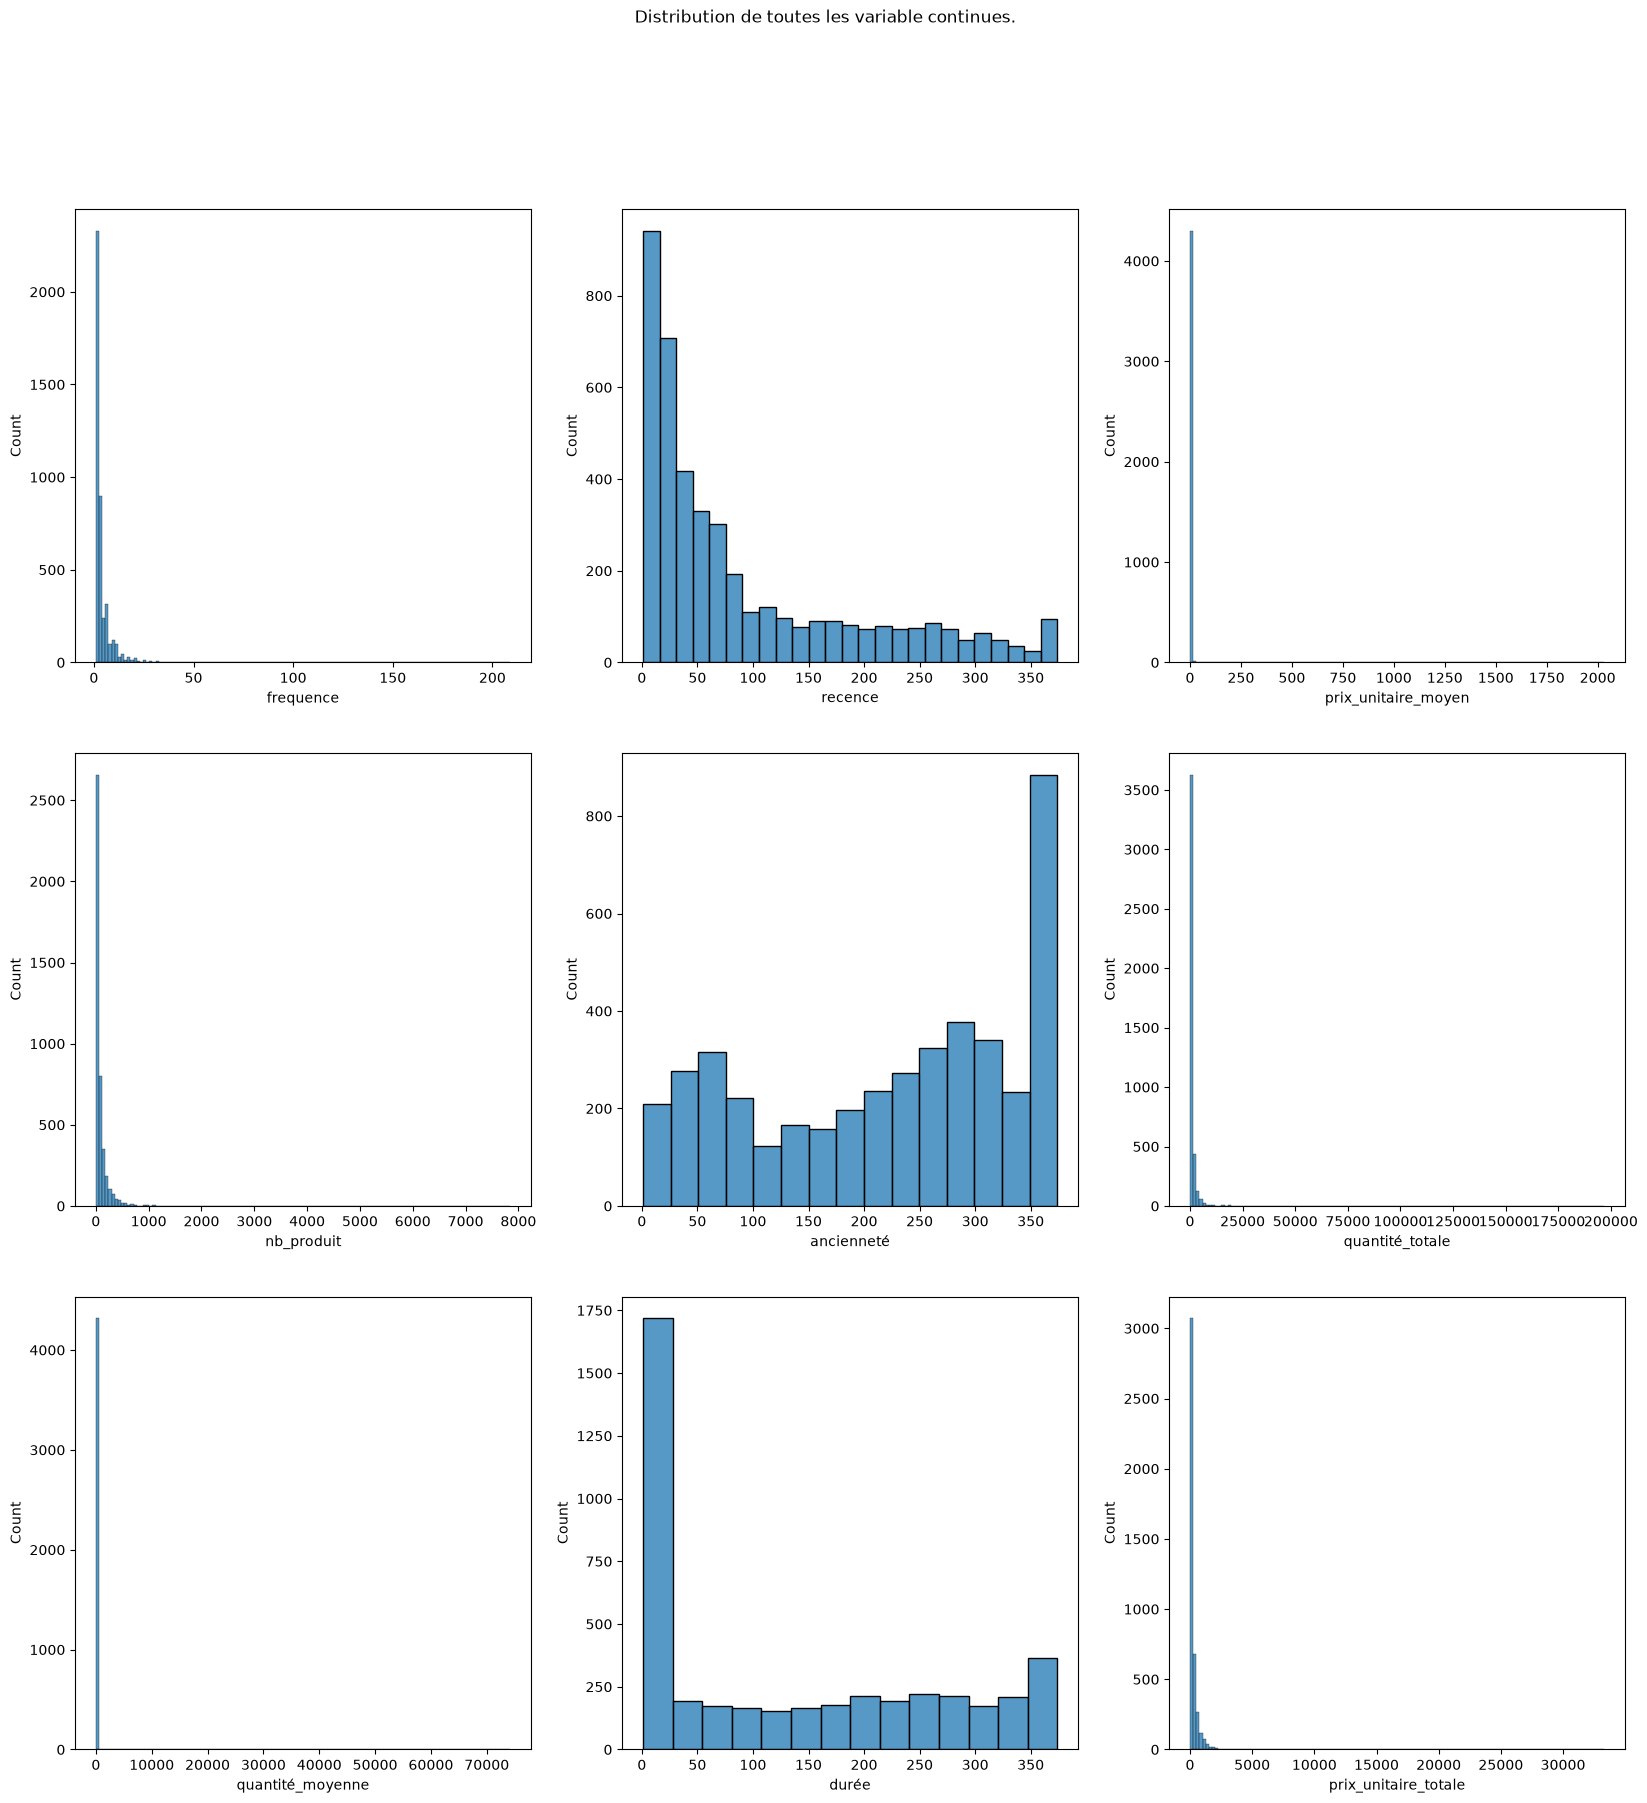

In [295]:
import seaborn as sns

fig, ax = plt.subplots(3, 3)
fig.set_size_inches(20, 20)
plt.suptitle("Distribution de toutes les variable continues.")
sns.histplot(data, x="frequence", ax=ax[0, 0])
sns.histplot(data, x="nb_produit", ax=ax[1, 0])
sns.histplot(data, x="quantité_moyenne", ax=ax[2, 0])
sns.histplot(data, x="recence", ax=ax[0, 1])
sns.histplot(data, x="ancienneté", ax=ax[1, 1])
sns.histplot(data, x="durée", ax=ax[2, 1])
sns.histplot(data, x="prix_unitaire_moyen", ax=ax[0, 2])
sns.histplot(data, x="quantité_totale", ax=ax[1, 2])
sns.histplot(data, x="prix_unitaire_totale", ax=ax[2, 2])
plt.show()

On voit que toutes les variables ne sont pas centré. On va donc appliqué un logarithme.

In [296]:
import numpy as np

data_log = data.copy()


data_log[data_log.select_dtypes(include="number").columns] = np.log1p(
    data_log[data_log.select_dtypes(include="number").columns]
)
data_log

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté,durée,prix_unitaire_moyen,prix_unitaire_totale
CustomerID,,,,,,,,,
12346.0,0.693147,0.693147,11.214735,11.214735,5.789960,5.789960,0.693147,0.712950,0.712950
12347.0,2.079442,5.209486,2.674528,7.807510,1.098612,5.908083,5.905362,1.293085,6.178380
12348.0,1.609438,3.465736,4.337502,7.758761,4.330733,5.883322,5.648974,1.911738,5.191344
12349.0,0.693147,4.304065,2.266319,6.448889,2.995732,2.995732,0.693147,2.228835,6.407045
12350.0,0.693147,2.890372,2.532763,5.288267,5.739793,5.739793,0.693147,1.577158,4.194190
...,...,...,...,...,...,...,...,...,...
18280.0,0.693147,2.397895,1.704748,3.828641,5.631212,5.631212,0.693147,1.751805,3.884652
18281.0,0.693147,2.079442,2.164964,4.007333,5.204007,5.204007,0.693147,1.890527,3.697839
18282.0,1.098612,2.564949,2.260025,4.644391,2.197225,4.844187,4.787492,1.824415,4.149306


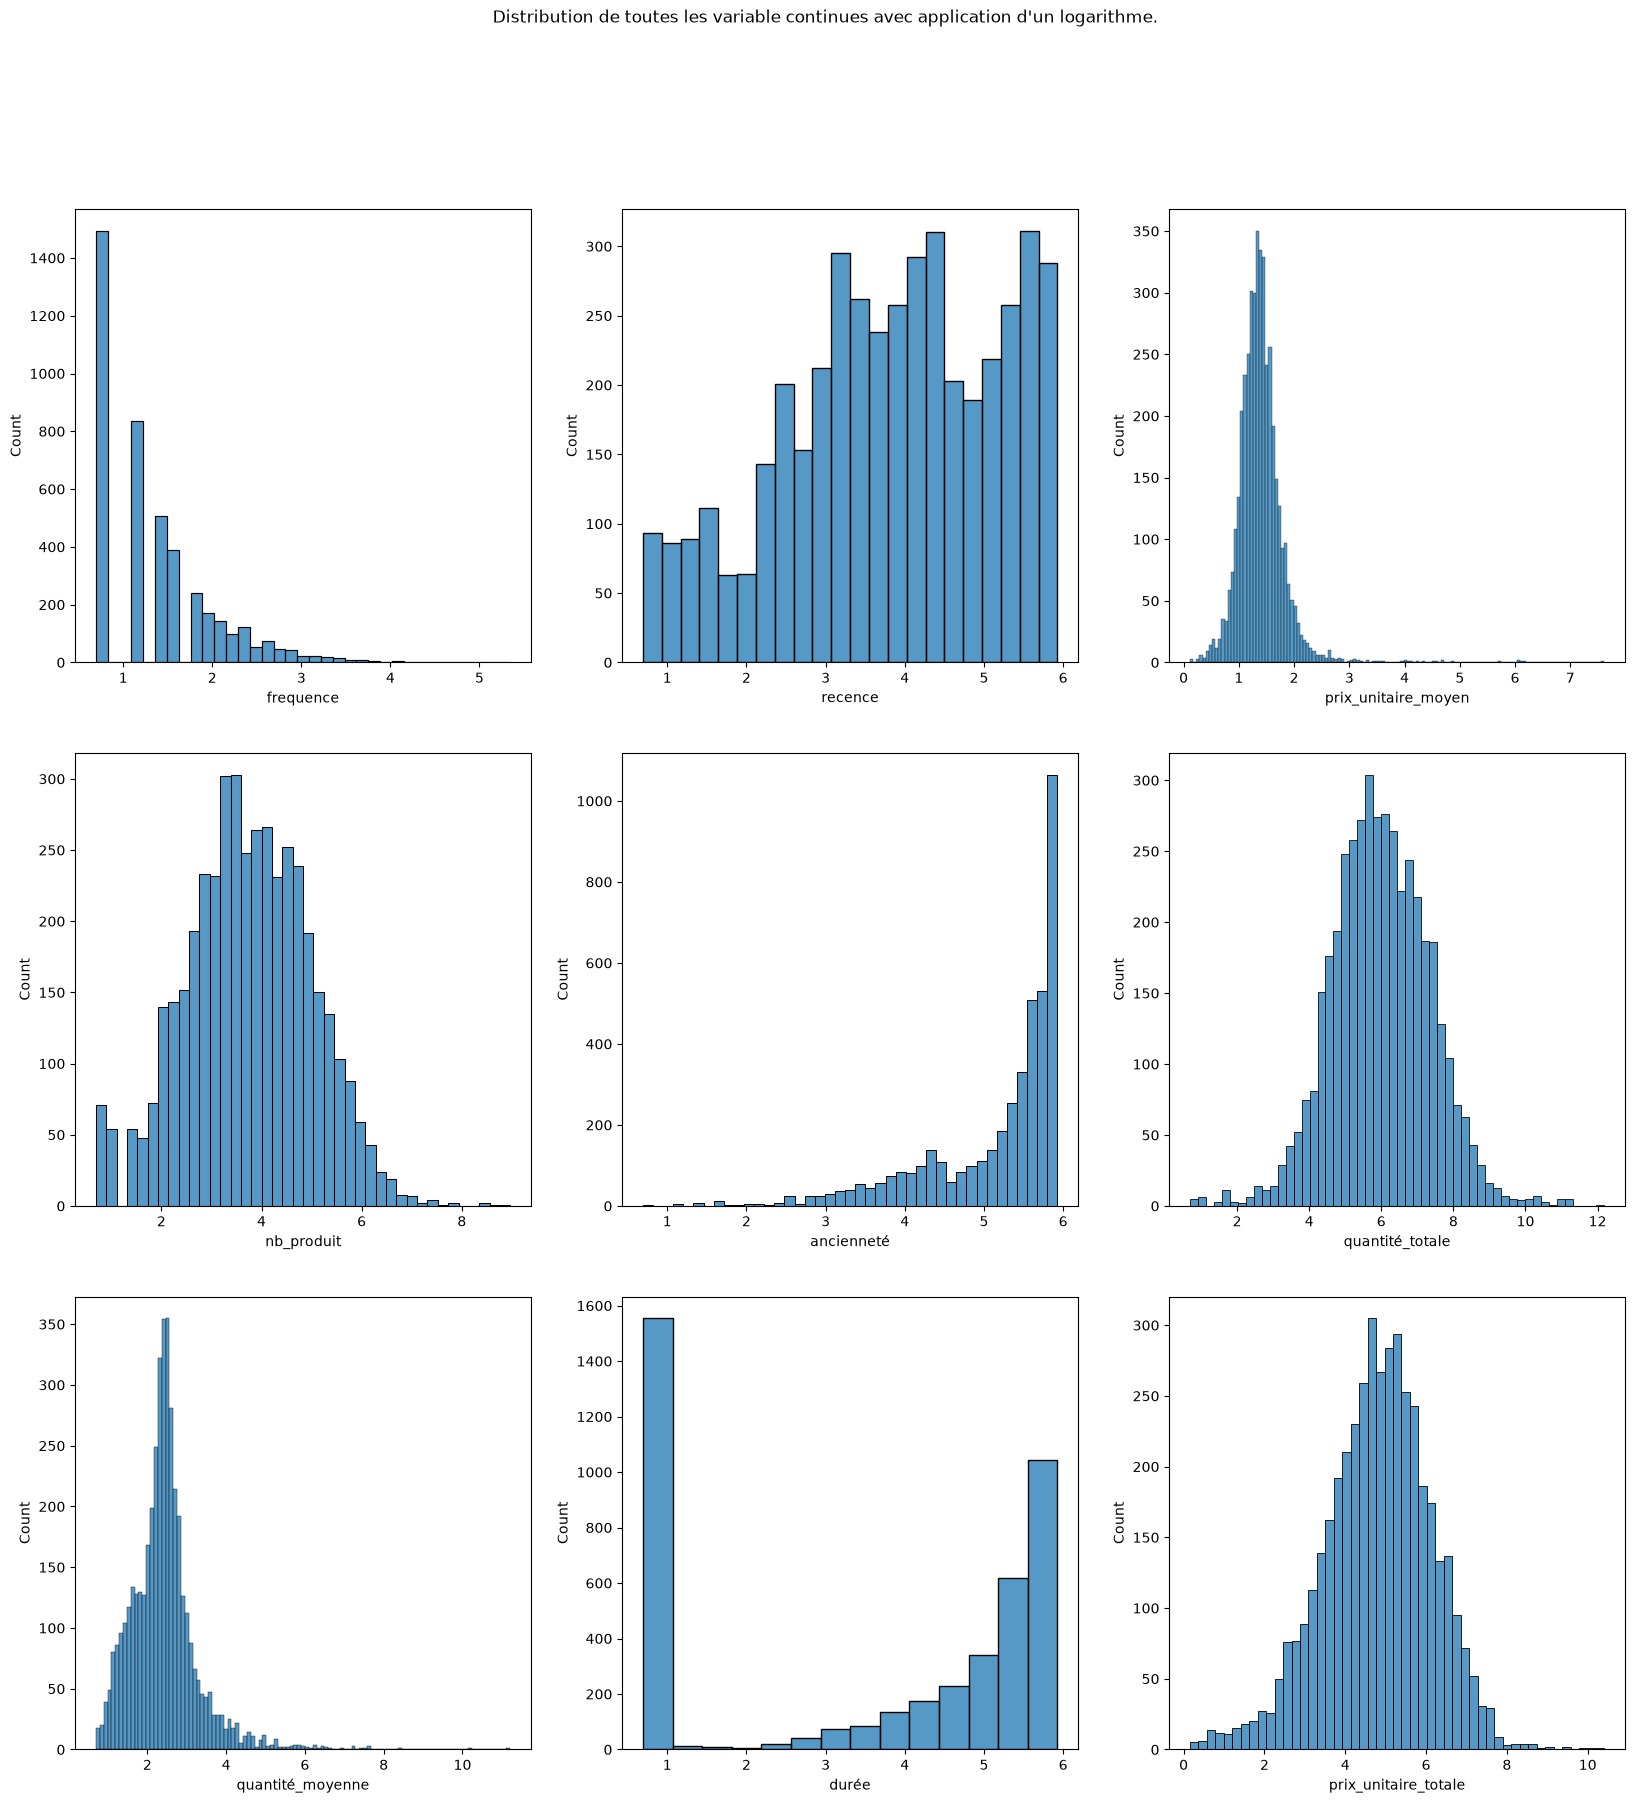

In [297]:
fig, ax = plt.subplots(3, 3)
fig.set_size_inches(20, 20)
plt.suptitle(
    "Distribution de toutes les variable continues avec application d'un logarithme."
)
sns.histplot(data_log, x="frequence", ax=ax[0, 0])
sns.histplot(data_log, x="nb_produit", ax=ax[1, 0])
sns.histplot(data_log, x="quantité_moyenne", ax=ax[2, 0])
sns.histplot(data_log, x="recence", ax=ax[0, 1])
sns.histplot(data_log, x="ancienneté", ax=ax[1, 1])
sns.histplot(data_log, x="durée", ax=ax[2, 1])
sns.histplot(data_log, x="prix_unitaire_moyen", ax=ax[0, 2])
sns.histplot(data_log, x="quantité_totale", ax=ax[1, 2])
sns.histplot(data_log, x="prix_unitaire_totale", ax=ax[2, 2])
plt.show()

On va maintenant regarder les corrélations.

<Axes: >

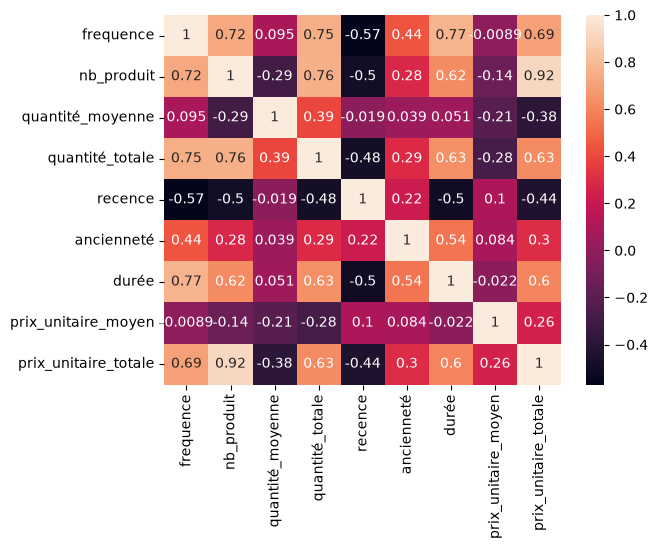

In [298]:
sns.heatmap(data_log.corr(), annot=True)

On voit que les deux variables prix_unitaire_totale et nb_produit sont trop corrélé. On va donc en supprimer un. On va faire notre modéle en testans avec l'un puis avec l'autre et on prend le meilleur résultat.

In [299]:
data_log1 = data_log.copy()

data_log1.drop(["prix_unitaire_totale"], axis=1, inplace=True)
data_log1

,frequence,nb_produit,quantité_moyenne,quantité_totale,recence,ancienneté,durée,prix_unitaire_moyen
CustomerID,,,,,,,,
12346.0,0.693147,0.693147,11.214735,11.214735,5.789960,5.789960,0.693147,0.712950
12347.0,2.079442,5.209486,2.674528,7.807510,1.098612,5.908083,5.905362,1.293085
12348.0,1.609438,3.465736,4.337502,7.758761,4.330733,5.883322,5.648974,1.911738
12349.0,0.693147,4.304065,2.266319,6.448889,2.995732,2.995732,0.693147,2.228835
12350.0,0.693147,2.890372,2.532763,5.288267,5.739793,5.739793,0.693147,1.577158
...,...,...,...,...,...,...,...,...
18280.0,0.693147,2.397895,1.704748,3.828641,5.631212,5.631212,0.693147,1.751805
18281.0,0.693147,2.079442,2.164964,4.007333,5.204007,5.204007,0.693147,1.890527
18282.0,1.098612,2.564949,2.260025,4.644391,2.197225,4.844187,4.787492,1.824415


On va maintenant faire une pca.

In [300]:
from sklearn.decomposition import PCA

data_pca_1 = PCA(n_components=2, random_state=42).fit_transform(data_log1)
data_pca_1

,pca0,pca1
CustomerID,,
12346.0,-1.510382,-0.101667
12347.0,4.140993,-1.260441
12348.0,2.265140,1.265318
12349.0,-1.928987,-2.966436
12350.0,-3.304491,0.832552
...,...,...
18280.0,-4.064681,1.153790
18281.0,-4.030326,0.675454
18282.0,0.400484,-0.165317


<Axes: xlabel='pca0', ylabel='pca1'>

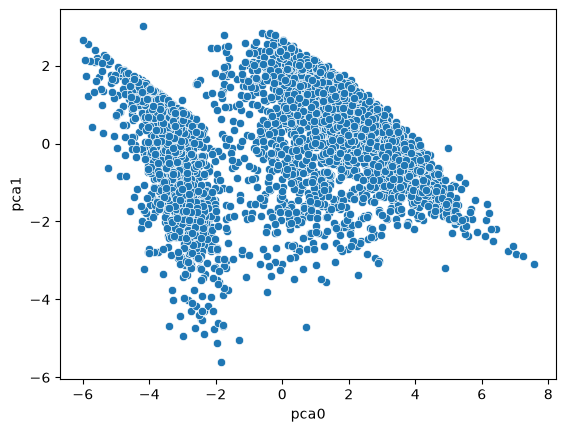

In [301]:
sns.scatterplot(data_pca_1, x="pca0", y="pca1")

In [302]:
data_log2 = data_log.copy()

data_log2.drop(["nb_produit"], axis=1, inplace=True)
data_log2

,frequence,quantité_moyenne,quantité_totale,recence,ancienneté,durée,prix_unitaire_moyen,prix_unitaire_totale
CustomerID,,,,,,,,
12346.0,0.693147,11.214735,11.214735,5.789960,5.789960,0.693147,0.712950,0.712950
12347.0,2.079442,2.674528,7.807510,1.098612,5.908083,5.905362,1.293085,6.178380
12348.0,1.609438,4.337502,7.758761,4.330733,5.883322,5.648974,1.911738,5.191344
12349.0,0.693147,2.266319,6.448889,2.995732,2.995732,0.693147,2.228835,6.407045
12350.0,0.693147,2.532763,5.288267,5.739793,5.739793,0.693147,1.577158,4.194190
...,...,...,...,...,...,...,...,...
18280.0,0.693147,1.704748,3.828641,5.631212,5.631212,0.693147,1.751805,3.884652
18281.0,0.693147,2.164964,4.007333,5.204007,5.204007,0.693147,1.890527,3.697839
18282.0,1.098612,2.260025,4.644391,2.197225,4.844187,4.787492,1.824415,4.149306


In [303]:
data_pca_2 = PCA(n_components=2, random_state=42).fit_transform(data_log2)
data_pca_2

,pca0,pca1
CustomerID,,
12346.0,-2.017916,0.226700
12347.0,4.101711,-1.302882
12348.0,2.490791,1.139206
12349.0,-1.555229,-2.991368
12350.0,-3.211110,0.934790
...,...,...
18280.0,-3.888968,1.131149
18281.0,-3.815285,0.588254
18282.0,0.598173,-0.525286


<Axes: xlabel='pca0', ylabel='pca1'>

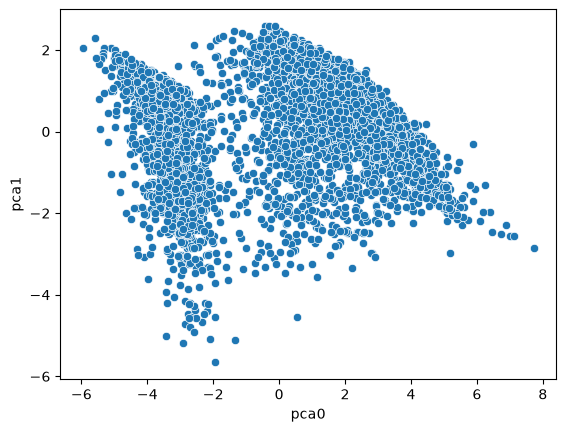

In [304]:
sns.scatterplot(data_pca_2, x="pca0", y="pca1")

Les deux surfaces sont trés similaire. On va garder le dataset avec le nombre de produit. Dans les deux cas on observe deux clusters.

<Axes: xlabel='pca0', ylabel='pca1'>

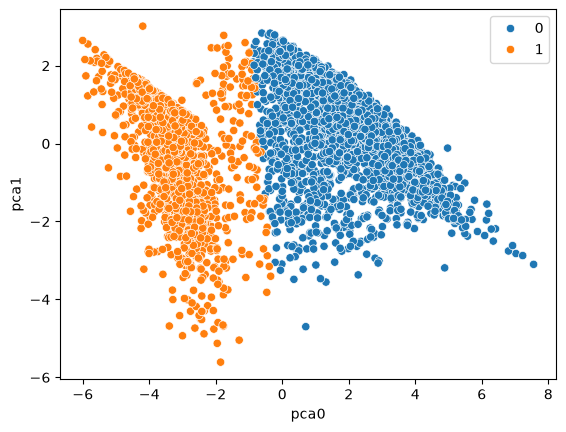

In [347]:
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN

cluster_Kmeans_2 = KMeans(n_clusters=2, random_state=42).fit_predict(data_pca_1)

sns.scatterplot(data_pca_1, x="pca0", y="pca1", hue=cluster_Kmeans_2)

<Axes: xlabel='pca0', ylabel='pca1'>

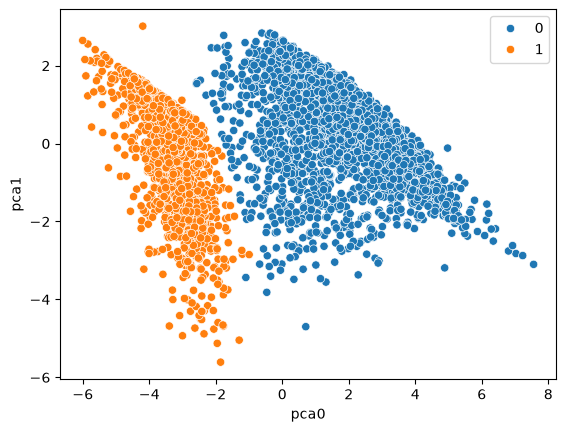

In [306]:
cluster_spectral_2 = SpectralClustering(
    n_clusters=2, random_state=42, gamma=40
).fit_predict(data_pca_1)

sns.scatterplot(data_pca_1, x="pca0", y="pca1", hue=cluster_spectral_2)

<Axes: xlabel='pca0', ylabel='pca1'>

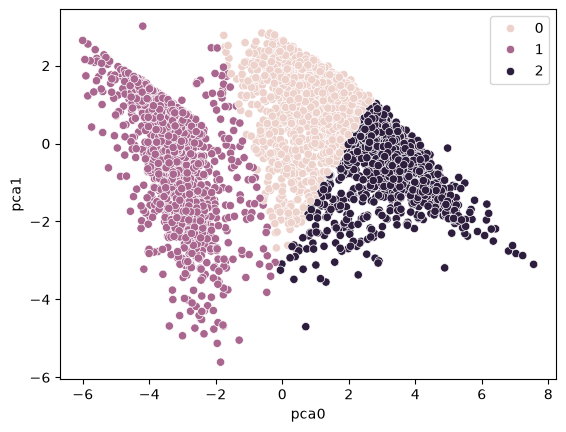

In [307]:
cluster_Kmeans_3 = KMeans(n_clusters=3, random_state=42).fit_predict(data_pca_1)

sns.scatterplot(data_pca_1, x="pca0", y="pca1", hue=cluster_Kmeans_3)

<Axes: xlabel='pca0', ylabel='pca1'>

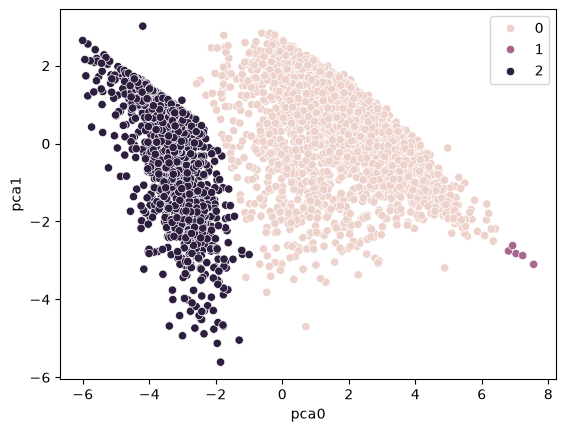

In [353]:
cluster_spectral_3 = SpectralClustering(
    n_clusters=3, random_state=42, gamma=15
).fit_predict(data_pca_1)

sns.scatterplot(data_pca_1, x="pca0", y="pca1", hue=cluster_spectral_3)

On arrive à clairement séparer deux cluster sur les trois avec le spectral clustering mais pas avec le Kmeans. Maintenant il faut rajouter de l'information pour séparer le troisiéme.